In [ ]:
# Import
import os
import numpy as np
from time import time
from scipy.io import wavfile as wav
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
import tarfile
from shutil import copyfile

#Data import

In [ ]:
# Link Google Drive account, transfer dataset, and extract files
drive.mount('/content/gdrive')
copyfile('gdrive/My Drive/recordings.tar', 'recordings.tar')
tar = tarfile.open('recordings.tar')
tar.extractall()
tar.close()

Mounted at /content/gdrive


In [ ]:
# Read the file 0_jackson_0.raw
sound_rate, sound_data = wav.read('recordings/0_jackson_0.wav')

In [ ]:
# Play the signal
ipd.Audio(sound_data, rate=sound_rate)

In [ ]:
# Shape of the audio array: 5148 values, one dimension
sound_data.shape

(5148,)

In [ ]:
# Sampling rate: 8000 samples per second
sound_rate

8000

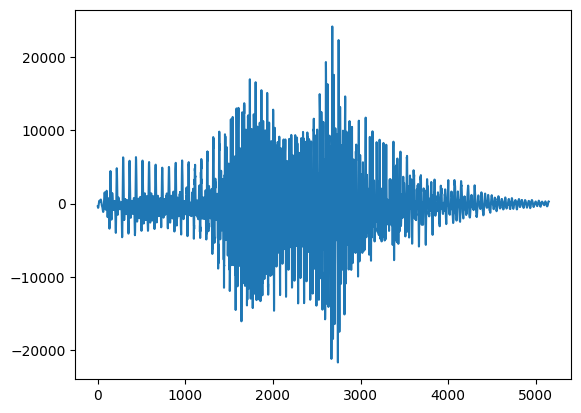

In [ ]:
# Show the signal plot
plt.plot(sound_data)

#Data loader

In [ ]:
# Placecholder for feature extractor
def identity(input):
    return input

# Data loader
def load_data(feature_extractor=identity, normalize=False):
    labels = []
    features = []
    for f in sorted(os.listdir('./recordings')):
        if f.endswith('.wav'):
            # Load file and compute the requested features
            _, signal = wav.read('./recordings/' + f)
            cur_features = feature_extractor(signal)
            features.append(cur_features)
            # Classes
            label = f.split('_')[0]
            labels.append(label)
    # X: features, y: labels
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=1)
    if normalize:
        eps = 0.001
        X_train = np.array(X_train)
        X_train_mean = X_train.mean(axis=0)
        X_train_std = X_train.std(axis=0)
        X_train = (X_train - X_train_mean + eps)/(X_train_std + eps)
        X_train = [row for row in X_train]
        X_test = [row for row in (np.array(X_test) - X_train_mean + eps)/(X_train_std + eps)]
    return X_train, X_test, y_train, y_test

#Features

These functions extract essential features from audio signals:  

- **Energy**: Computes the signal's energy by summing the squared samples. It helps measure the signal's intensity or volume.  
- **Duration**: Returns the length of the signal (number of samples), representing its duration in terms of data points.  
- **Zero-crossing rate**: Counts the number of times the signal changes sign, useful for analyzing frequency and tonal characteristics.

In [ ]:
# Define the following functions: energy, duration, zero-crossing rate
def energy(input):
  return np.sum((input*1.0)**2, keepdims=True)

def duration(input):
  return np.array(input.shape)

def zero_cross(input):
  new = input[1:]
  return np.sum(np.sign(input[:-1]) != np.sign(new), keepdims=True)

##*Zero-Crossing Rate*

A Support Vector Machine with kernel based on the Radial Basis Function (RBF) is used to perform the classification task.
The default parameters are replaced with a search for optimal ones performed through the GridSearch method.

In [ ]:
# Data loading
X_train, X_test, y_train, y_test = load_data(feature_extractor=zero_cross)

In [ ]:
# Parameters to be tested in cross-validation
param_grid = {'C': [100, 500, 1000],
          'gamma': [0.005, 0.01, 0.1, 0.5, 1.0], }

# Support Vector Machine initialization
clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=2)

# Training
t0 = time()
clf = clf.fit(X_train, y_train)
print('Training completed in %0.3fs' % (time() - t0))

Training completed in 4.563s


In [ ]:
# Result of the cross validation for parameters selection
print('Best parameters combination:')
print(' C: '+str(clf.best_estimator_.C))
print(' gamma: '+str(clf.best_estimator_.gamma))

Best parameters combination:
 C: 100
 gamma: 0.005


In [ ]:
# SVM test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.20      0.24      0.22        17
           1       0.13      0.20      0.16        10
           2       0.08      0.07      0.07        15
           3       0.26      0.32      0.29        19
           4       0.14      0.18      0.16        11
           5       0.07      0.07      0.07        14
           6       0.47      0.50      0.48        14
           7       0.22      0.11      0.14        19
           8       0.18      0.18      0.18        17
           9       0.09      0.07      0.08        14

    accuracy                           0.19       150
   macro avg       0.18      0.19      0.18       150
weighted avg       0.19      0.19      0.19       150



Confusion matrix:


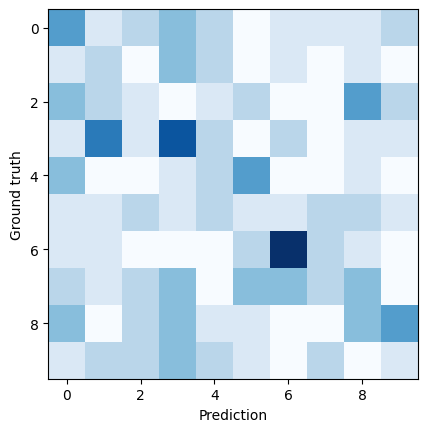

In [ ]:
# Confusion matrix
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap=plt.cm.Blues);
plt.xlabel('Prediction');
plt.ylabel('Ground truth');

The results indicate that signal classification based solely on the **zero-crossing rate (ZCR)** feature is ineffective.  

- Accuracy of 27% is close to random guessing.
- The majority of the classes present low values of precision, recall, and F1-score suggesting that ZCR alone does not provide sufficient information for classification.
- The classes: zero, five and nine have a precision, recall, and F1-score of zero, meaning the model failed to correctly classify any samples from those classes.  
- The fourth class present an high recall and a low precision suggesting the presence of many false positives for that class.  
- The sixth class shows relatively better performance, indicating that ZCR may carry useful information for this class but is not robust overall.  


##*Features combination*
- All the features: energy, duration and zero_cross are combined together using the function combo2
- The features: energy and zero_cross are combined together using the function combo3
- The features: duration and zero_cross are combined together using the function combo4

In [ ]:
# Define the combinantion functions
def combo2(input):
  return np.concatenate((energy(input), duration(input), zero_cross(input)))

def combo3(input):
  return np.concatenate((energy(input), zero_cross(input)))

def combo4(input):
  return np.concatenate((duration(input), zero_cross(input)))

###Feature combination - combo2: *Energy*, *Duration* and *ZCR*

A Support Vector Machine with kernel based on the Radial Basis Function (RBF) is used to perform the classification task.
The default parameters are replaced with a search for optimal ones performed through the GridSearch method.

In [ ]:
# Data loading
X_train, X_test, y_train, y_test = load_data(feature_extractor=combo2, normalize=True)

In [ ]:
# Parameters to be tested in cross-validation
param_grid = {'C': [100, 500, 1000],
          'gamma': [0.005, 0.01, 0.1, 0.5, 1.0], }

# Support Vector Machine initialization
clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=2)

# Training
t0 = time()
clf = clf.fit(X_train, y_train)
print('Training completed in %0.3fs' % (time() - t0))

Training completed in 3.331s


In [ ]:
# Result of the cross validation for parameters selection
print('Best parameters combination:')
print(' C: '+str(clf.best_estimator_.C))
print(' gamma: '+str(clf.best_estimator_.gamma))

Best parameters combination:
 C: 1000
 gamma: 0.5


In [ ]:
# SVM test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.65      0.61        17
           1       0.35      0.70      0.47        10
           2       0.43      0.40      0.41        15
           3       0.60      0.32      0.41        19
           4       0.38      0.55      0.44        11
           5       0.31      0.36      0.33        14
           6       0.81      0.93      0.87        14
           7       0.29      0.11      0.15        19
           8       0.60      0.53      0.56        17
           9       0.59      0.71      0.65        14

    accuracy                           0.50       150
   macro avg       0.49      0.52      0.49       150
weighted avg       0.50      0.50      0.48       150



Confusion matrix:


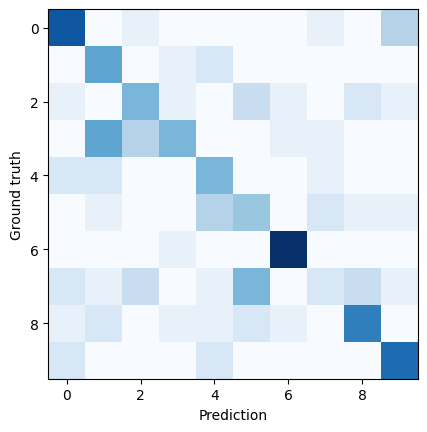

In [ ]:
# Confusion matrix
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap=plt.cm.Blues);
plt.xlabel('Prediction');
plt.ylabel('Ground truth');

The results indicate that signal classification based on the combination of all the features is actually the most effective one.  

- Accuracy of 50% indicates that the extracted features provide adeguate information.
- The majority of the classes present moderately high values of precision, recall, and F1-score suggesting that the combination of all the fetures provide sufficient information for classification.
- The seventh class present the lowest values of precision, recall and F1-score suggesting that the model failed to correctly classify most samples from this class.  
- The sixth class shows impressively better performance, indicating that the combination of all the features may carry useful information for this class.  


### Features combination - combo3: *Energy* and *ZCR*

A Support Vector Machine with kernel based on the Radial Basis Function (RBF) is used to perform the classification task.
The default parameters are replaced with a search for optimal ones performed through the GridSearch method.

In [ ]:
# Data loading
X_train, X_test, y_train, y_test = load_data(feature_extractor=combo3, normalize=True)

In [ ]:
# Parameters to be tested in cross-validation
param_grid = {'C': [100, 500, 1000],
          'gamma': [0.005, 0.01, 0.1, 0.5, 1.0], }

# Support Vector Machine initialization
clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=2)

# Training
t0 = time()
clf = clf.fit(X_train, y_train)
print('Training completed in %0.3fs' % (time() - t0))

Training completed in 5.466s


In [ ]:
# Result of the cross validation for parameters selection
print('Best parameters combination:')
print(' C: '+str(clf.best_estimator_.C))
print(' gamma: '+str(clf.best_estimator_.gamma))

Best parameters combination:
 C: 500
 gamma: 1.0


In [ ]:
# SVM test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.27      0.24      0.25        17
           1       0.22      0.80      0.34        10
           2       0.30      0.40      0.34        15
           3       0.36      0.21      0.27        19
           4       0.25      0.09      0.13        11
           5       0.08      0.07      0.08        14
           6       0.75      0.64      0.69        14
           7       0.22      0.11      0.14        19
           8       0.50      0.35      0.41        17
           9       0.39      0.50      0.44        14

    accuracy                           0.32       150
   macro avg       0.33      0.34      0.31       150
weighted avg       0.34      0.32      0.31       150



Confusion matrix:


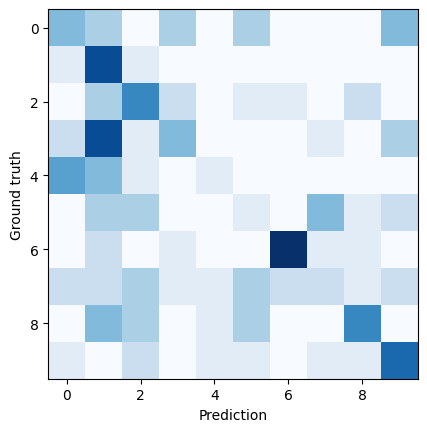

In [ ]:
# Confusion matrix
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap=plt.cm.Blues);
plt.xlabel('Prediction');
plt.ylabel('Ground truth');

The results indicate that signal classification based on the combination of energy and ZCR features is slightly more effective than the ZCR alone.  

- Accuracy of 32% indicates that the extracted features provide more information than the ZCR alone but less than the combination of all the three features.
- The majority of the classes present low values of precision, recall, and F1-score suggesting that the the model doesn't have sufficient information for classification.
- The fifth classe present the lowest values of precision, recall and F1-score suggesting that the model failed to correctly classify most samples from this class.  
- The sixth class shows the highest values of precision, recall and F1-score, but still slightly higher than 50%.  

### Feature combination - combo4: *Duration* and *ZCR*

A Support Vector Machine with kernel based on the Radial Basis Function (RBF) is used to perform the classification task.
The default parameters are replaced with a search for optimal ones performed through the GridSearch method.

In [ ]:
# Data loading
X_train, X_test, y_train, y_test = load_data(feature_extractor=combo4, normalize=True)

In [ ]:
# Parameters to be tested in cross-validation
param_grid = {'C': [100, 500, 1000],
          'gamma': [0.005, 0.01, 0.1, 0.5, 1.0], }

# Support Vector Machine initialization
clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=2)

# Training
t0 = time()
clf = clf.fit(X_train, y_train)
print('Training completed in %0.3fs' % (time() - t0))

Training completed in 3.887s


In [ ]:
# Result of the cross validation for parameters selection
print('Best parameters combination:')
print(' C: '+str(clf.best_estimator_.C))
print(' gamma: '+str(clf.best_estimator_.gamma))

Best parameters combination:
 C: 500
 gamma: 0.5


In [ ]:
# SVM test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.29      0.37        17
           1       0.41      0.70      0.52        10
           2       0.26      0.40      0.32        15
           3       0.50      0.26      0.34        19
           4       0.23      0.45      0.30        11
           5       0.10      0.07      0.08        14
           6       0.87      0.93      0.90        14
           7       0.17      0.16      0.16        19
           8       0.45      0.29      0.36        17
           9       0.57      0.57      0.57        14

    accuracy                           0.39       150
   macro avg       0.41      0.41      0.39       150
weighted avg       0.41      0.39      0.38       150



Confusion matrix:


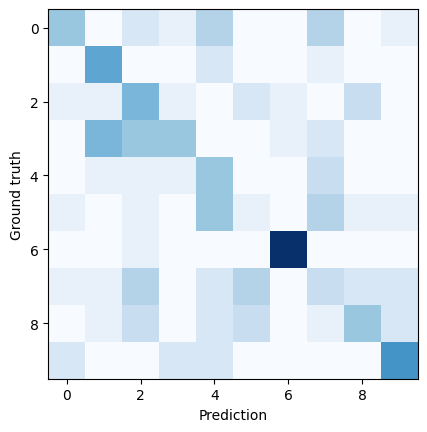

In [ ]:
# Confusion matrix
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap=plt.cm.Blues);
plt.xlabel('Prediction');
plt.ylabel('Ground truth');

The results indicate that signal classification based on the combination of duration and ZCR features is slightly more effective than the ZCR alone.  

- Accuracy of 39% indicates that the extracted features provide more information than the ZCR alone but less than the combination of all the three features.
- The majority of the classes present low values of precision, recall, and F1-score suggesting that the the model doesn't have sufficient information for classification.
- The fifth classe present the lowest values of precision, recall and F1-score suggesting that the model failed to correctly classify most samples from this class.  
- The sixth class shows the highest values of precision, recall and F1-score.   